In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray
import ipdb

In [2]:
# load the start and end rows and columns of a chunk product on the full disk grid for a channel
def load_channel_chunk_grid_parameters(product,channel):
    dataset = nc.Dataset(product,'r')
    
    start_row_index = dataset[f'data/{channel}/measured/start_position_row'][:] - 1
    end_row_index = dataset[f'data/{channel}/measured/end_position_row'][:] - 1
    start_column_index = dataset[f'data/{channel}/measured/start_position_column'][:] - 1
    end_column_index = dataset[f'data/{channel}/measured/end_position_column'][:] - 1
    channel_ssd = dataset[f'data/{channel}/ssd_index'][:]
    
    dataset.close()
    
    return start_row_index,end_row_index,start_column_index,end_column_index,channel_ssd

In [3]:
#SSDS = ['0.5km', '1km'] # for VIS files
SSDS = ['1km', '2km']  # for IR files

# load the parameters configuring the geostationary projection-based grid
def load_grid_parameters(product):
    dataset = nc.Dataset(product,'r')
    
    grid_parameters = {}
    
    # ssd independent parameters
    mtg_geos_projection = dataset['data/mtg_geos_projection']
    grid_parameters['semi_major_axis']                = mtg_geos_projection.semi_major_axis
    grid_parameters['semi_minor_axis']                = mtg_geos_projection.semi_minor_axis
    grid_parameters['perspective_point_height']       = mtg_geos_projection.perspective_point_height
    grid_parameters['longitude_of_projection_origin'] = mtg_geos_projection.longitude_of_projection_origin
    
    # ssd dependent parameters
    reference_grids                          = dataset['state/processor/reference_grid'][:]
    reference_grid_number_of_rows            = dataset['state/processor/reference_grid_number_of_rows'][:]
    reference_grid_number_of_columns         = dataset['state/processor/reference_grid_number_of_columns'][:]
    reference_grid_spatial_sampling_angle_ns = dataset['state/processor/reference_grid_spatial_sampling_angle_ns'][:]
    reference_grid_spatial_sampling_angle_ew = dataset['state/processor/reference_grid_spatial_sampling_angle_ew'][:]

    #ipdb.set_trace()
    
    for grid_index in range(len(reference_grids)):
        ssd_index = grid_index
        print(ssd_index)
        ssd = SSDS[ssd_index]
        grid_parameters[ssd] = {}
        grid_parameters[ssd]['azimuth_grid_sampling']   = reference_grid_spatial_sampling_angle_ns[grid_index]
        grid_parameters[ssd]['elevation_grid_sampling'] = reference_grid_spatial_sampling_angle_ew[grid_index]
        grid_parameters[ssd]['azimuth0']   =   reference_grid_spatial_sampling_angle_ns[grid_index] * (reference_grid_number_of_rows[grid_index]    / 2 - 0.5)
        grid_parameters[ssd]['elevation0'] = - reference_grid_spatial_sampling_angle_ew[grid_index] * (reference_grid_number_of_columns[grid_index] / 2 - 0.5)
        grid_parameters[ssd]['reference_grid_number_of_rows']    = reference_grid_number_of_rows[grid_index]
        grid_parameters[ssd]['reference_grid_number_of_columns'] = reference_grid_number_of_columns[grid_index]
    
    dataset.close()
    
    return grid_parameters

In [4]:
def plot_data(data,title):
    plt.figure(figsize=(20,10))
    plt.tight_layout()
    plt.imshow(data)
    plt.title(title)
    plt.show()

In [19]:
# transform rows and columns to latitudes and longitudes
def grid_coordinates_to_geo_coordinates(rows, columns, grid_parameters, ssd, lat_print=False, lon_print=False):
    shape = rows.shape
    print(shape)

    azimuth   = grid_parameters[ssd]['azimuth0']   - columns * grid_parameters[ssd]['azimuth_grid_sampling']
    elevation = grid_parameters[ssd]['elevation0'] + rows    * grid_parameters[ssd]['elevation_grid_sampling']
    
    s4 = (grid_parameters['semi_major_axis'] / grid_parameters['semi_minor_axis'])**2
    h = grid_parameters['perspective_point_height'] + grid_parameters['semi_major_axis']
    s5 = h**2 - grid_parameters['semi_major_axis']**2
    
    a = np.cos(elevation)**2 + s4 * np.sin(elevation)**2
    b = - 2 * h * np.cos(azimuth) * np.cos(elevation)
    c = s5
    
    sd2 = b**2 - 4 * a * c
    earth_mask = (sd2 >= 0)
    sd = np.nan * np.ones(shape)
    sd[earth_mask] = np.sqrt(sd2[earth_mask])
    
    sn = (- b - sd) / (2 * a)
    
    s1 = h - sn * np.cos(azimuth) * np.cos(elevation)
    s2 = -sn * np.sin(azimuth) * np.cos(elevation)
    s3 = sn * np.sin(elevation)
    
    sxy = np.sqrt(s1**2 + s2**2)

    lons = None
    if lon_print==True:
        lons = np.rad2deg(np.arctan(s2 / s1)) + grid_parameters['longitude_of_projection_origin']

    lats = None
    if lat_print==True:
        lats = np.rad2deg(np.arctan(s4 * s3 / sxy))
    
    return lats,lons

In [6]:
# run configuration
#product = 'W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20241024103903_IDPFI_OPE_20241024103604_20241024103633_N__C_0064_0026.nc'
#normalres: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20241024103903_IDPFI_OPE_20241024103604_20241024103633_N__C_0064_0026.nc
#Highres: W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--CHK-BODY---NC4E_C_EUMT_20241024103806_IDPFI_OPE_20241024103525_20241024103555_N__C_0064_0024.nc
product = '/users/global/cornkle/EUMDAC_MTG_TESTS/W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-FDHSI-FD--CHK-BODY---NC4E_C_EUMT_20260409151053_IDPFI_OPE_20260409150857_20260409150929_N__O_0091_0038.nc'
#W_XX-EUMETSAT-Darmstadt,IMG+SAT,MTI1+FCI-1C-RRAD-HRFI-FD--CHK-BODY---NC4E_C_EUMT_20241213150905_IDPFI_OPE_20241213150614_20241213150652_N__O_0091_0027.nc'
ds = xr.open_dataset(product)
ssd = '2km'
channel = 'ir_105'

In [7]:
# load the grid parameters
grid_parameters = load_grid_parameters(product)

# load the grid coordinates for a channel in a chunk product
start_row_index,end_row_index,start_column_index,end_column_index,channel_ssd = load_channel_chunk_grid_parameters(product,channel)

0
1


In [8]:
grid_parameters

{'semi_major_axis': np.float64(6378137.0),
 'semi_minor_axis': np.float64(6356752.31424518),
 'perspective_point_height': np.float64(35786400.0),
 'longitude_of_projection_origin': np.float64(0.0),
 '1km': {'azimuth_grid_sampling': np.float64(2.79435763233999e-05),
  'elevation_grid_sampling': np.float64(2.79435763233999e-05),
  'azimuth0': np.float64(0.15557586118052893),
  'elevation0': np.float64(-0.15557586118052893),
  'reference_grid_number_of_rows': np.uint32(11136),
  'reference_grid_number_of_columns': np.uint32(11136)},
 '2km': {'azimuth_grid_sampling': np.float64(5.58871526031607e-05),
  'elevation_grid_sampling': np.float64(5.58871526031607e-05),
  'azimuth0': np.float64(0.1555618892708978),
  'elevation0': np.float64(-0.1555618892708978),
  'reference_grid_number_of_rows': np.uint32(5568),
  'reference_grid_number_of_columns': np.uint32(5568)}}

In [9]:
ssd

'2km'

In [23]:
# determine the geolocation for the selected channel in the selected chunk product 
chunk_rs,chunk_cs = np.mgrid[start_row_index:end_row_index+1,start_column_index:end_column_index+1]
chunk_lats,chunk_lons = grid_coordinates_to_geo_coordinates(chunk_rs,chunk_cs,grid_parameters,ssd, lat_print=True, lon_print=True)

(139, 5568)


In [24]:
chunk_lats

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(139, 5568))

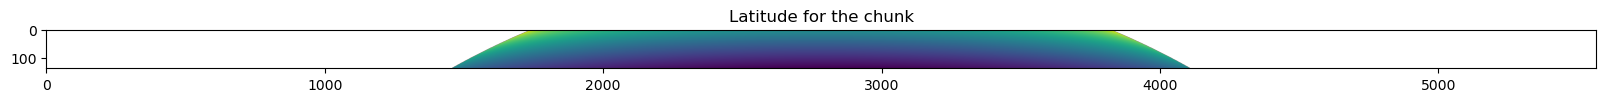

In [25]:
plot_data(chunk_lats[::-1],'Latitude for the chunk')

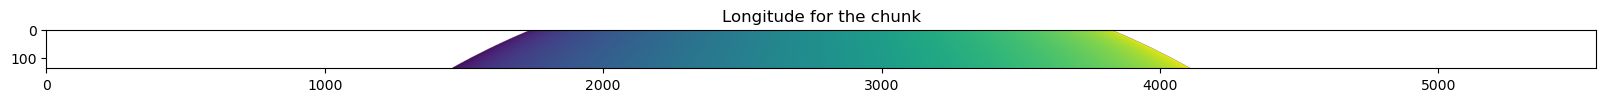

In [26]:
plot_data(chunk_lons[::-1],'Longitude for the chunk')

In [32]:
# determine the geolocation for the full disk grid for a specific SSD
rs,cs = np.indices((grid_parameters[ssd]['reference_grid_number_of_rows'],grid_parameters[ssd]['reference_grid_number_of_columns']))
lats,lons = grid_coordinates_to_geo_coordinates(rs,cs,grid_parameters,ssd, lat_print=True, lon_print=True)

(5568, 5568)


In [33]:
cs

array([[   0,    1,    2, ..., 5565, 5566, 5567],
       [   0,    1,    2, ..., 5565, 5566, 5567],
       [   0,    1,    2, ..., 5565, 5566, 5567],
       ...,
       [   0,    1,    2, ..., 5565, 5566, 5567],
       [   0,    1,    2, ..., 5565, 5566, 5567],
       [   0,    1,    2, ..., 5565, 5566, 5567]], shape=(5568, 5568))

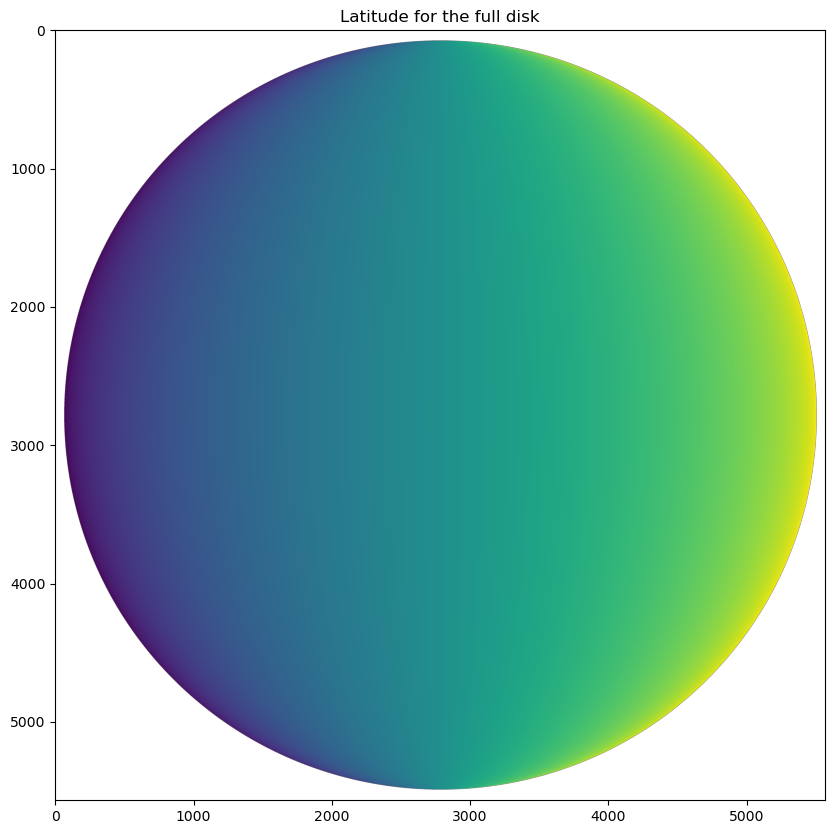

In [34]:
plot_data(lons,'Latitude for the full disk')

In [15]:
import xarray as xr

In [17]:
lats[4000:4010,7000]-lats[4001:4011,7000]

array([-0.00957085, -0.0095702 , -0.00956954, -0.00956889, -0.00956824,
       -0.00956759, -0.00956694, -0.00956629, -0.00956564, -0.00956499])

In [18]:
lons[4000,7000:7010]-lons[4000,7001:7011]

array([-0.00976101, -0.00976166, -0.00976231, -0.00976295, -0.0097636 ,
       -0.00976425, -0.0097649 , -0.00976555, -0.0097662 , -0.00976685])

In [22]:
lats.shape

(11136, 11136)

In [37]:
x = np.arange(len(lons[0,:]))    # 1D x-coordinate
y = np.arange(len(lons[0,:]))     # 1D y-coordinate

ds = xr.Dataset(
    {
        "latitude": (("y", "x"), lats),
        "longitude": (("y", "x"), lons)
    },
    coords={
        "x": ("x", x),
        "y": ("y", y)
    }
)

# Define compression settings
compression = {"zlib": True, "complevel": 5}




# Save the dataset to a NetCDF file
ds.to_netcdf("/users/global/cornkle/EUMDAC_MTG_TESTS/mtg_coords_2km.nc", format="NETCDF4", engine="netcdf4", encoding={
        "latitude": compression,
        "longitude": compression
    })